In [4]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    ROOT,
    TARGET,
    build_pipeline,
    evaluate_classification,
    get_classification_split,
    load_ml_dataframe,
    make_high_salary_label,
)

MODEL_NAME = "random_forest_classifier"
ml_df = load_ml_dataframe()
# step 13
X_train, X_test, y_train, y_test = get_classification_split()

print("target column", TARGET, "1 means at or above median salary")
print("low vs high salary in full dataset")
print(make_high_salary_label(ml_df).value_counts(normalize=True).rename({0: "low", 1: "high"}))

pipeline = build_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=10,
        class_weight="balanced",  # step 13
    )
)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

metrics, report_dict = evaluate_classification(y_test, y_pred, model_name=MODEL_NAME)

results_df = pd.DataFrame([metrics])
results_df.to_csv(ROOT / "data" / f"results_{MODEL_NAME}.csv", index=False)
results_df


target column ConvertedCompYearly 1 means at or above median salary
low vs high salary in full dataset
ConvertedCompYearly
high    0.686771
low     0.313229
Name: proportion, dtype: float64


,model,accuracy,f1_score,precision_0,recall_0,f1_score_0,support_0,precision_1,recall_1,f1_score_1,support_1
0,random_forest_classifier,0.60984,0.68535,0.413939,0.590335,0.486646,1821,0.768035,0.618737,0.68535,3992


In [5]:
print(classification_report(y_test, y_pred, target_names=["low", "high"]))

print("accuracy", round(metrics["accuracy"], 4))
print("f1 score", round(metrics["f1_score"], 4))
print("low salary class")
print("  precision", round(metrics["precision_0"], 4))
print("  recall", round(metrics["recall_0"], 4))
print("  f1", round(metrics["f1_score_0"], 4))
print("  support", metrics["support_0"])
print("high salary class")
print("  precision", round(metrics["precision_1"], 4))
print("  recall", round(metrics["recall_1"], 4))
print("  f1", round(metrics["f1_score_1"], 4))
print("  support", metrics["support_1"])

support_table = pd.DataFrame(
    {
        "class": ["low (0)", "high (1)"],
        "support_in_test_set": [
            int((y_test == 0).sum()),
            int((y_test == 1).sum()),
        ],
    }
)
support_table


              precision    recall  f1-score   support

         low       0.41      0.59      0.49      1821
        high       0.77      0.62      0.69      3992

    accuracy                           0.61      5813
   macro avg       0.59      0.60      0.59      5813
weighted avg       0.66      0.61      0.62      5813

accuracy 0.6098
f1 score 0.6853
low salary class
  precision 0.4139
  recall 0.5903
  f1 0.4866
  support 1821
high salary class
  precision 0.768
  recall 0.6187
  f1 0.6853
  support 3992


,class,support_in_test_set
0,low (0),1821
1,high (1),3992


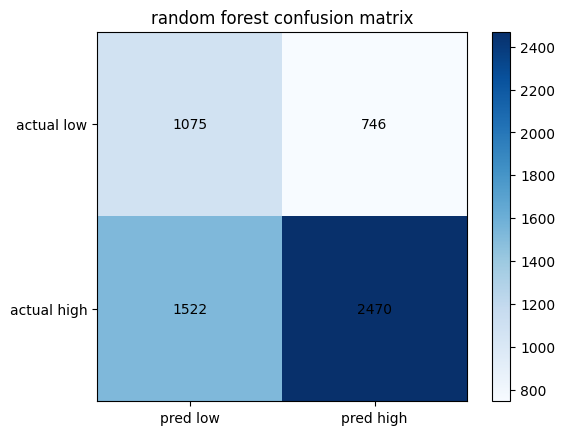

,pred_low,pred_high
actual_low,1075,746
actual_high,1522,2470


In [6]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["actual_low", "actual_high"],
    columns=["pred_low", "pred_high"],
)
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["pred low", "pred high"])
plt.yticks([0, 1], ["actual low", "actual high"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("random forest confusion matrix")
plt.colorbar()
plt.show()
cm_df